## I want you to use this data to predict rainfall, minimum and maximum temperature
## Use this information to predict from 2021-2024
## Use 1984 to 2000 --- training 
## Use 2001- 2023 ----- validation
## Use this information to predict from 2021-2024
## Use Mann Kendall formula to determine the trend of these parameters

# Using Mann Kendall Formula to determine the trend of Rainfall for each months and predicting future Rainfall

### Importing the neccessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk

In [2]:
rainfall = pd.read_excel("C:/Users/ALGORITHM/Documents/DATA SET/Shiro Data.xlsx", sheet_name = "PRE")

In [3]:
df = pd.read_excel("C:/Users/ALGORITHM/Documents/DATA SET/Shiro Data.xlsx", sheet_name = "PRE")

## Data Understanding

In [4]:
rainfall.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2,NaN,1980.0,0,2.5,1.9,28,211.1,102.6,245.5,269.1,177.8,112.8,0,0.4
3,NaN,1981.0,0.5,0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0,0.2
4,NaN,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0,0.2


In [5]:
rainfall.shape

(44, 14)

In [6]:
rainfall.dtypes

Unnamed: 0     float64
Unnamed: 1     float64
Unnamed: 2      object
Unnamed: 3      object
Unnamed: 4      object
Unnamed: 5      object
Unnamed: 6      object
Unnamed: 7      object
Unnamed: 8      object
Unnamed: 9      object
Unnamed: 10     object
Unnamed: 11     object
Unnamed: 12     object
Unnamed: 13     object
dtype: object

In [7]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   0 non-null      float64
 1   Unnamed: 1   42 non-null     float64
 2   Unnamed: 2   43 non-null     object 
 3   Unnamed: 3   43 non-null     object 
 4   Unnamed: 4   43 non-null     object 
 5   Unnamed: 5   43 non-null     object 
 6   Unnamed: 6   43 non-null     object 
 7   Unnamed: 7   43 non-null     object 
 8   Unnamed: 8   43 non-null     object 
 9   Unnamed: 9   43 non-null     object 
 10  Unnamed: 10  43 non-null     object 
 11  Unnamed: 11  43 non-null     object 
 12  Unnamed: 12  43 non-null     object 
 13  Unnamed: 13  43 non-null     object 
dtypes: float64(2), object(12)
memory usage: 4.9+ KB


#### From the above understanding, the dataset is noisy. It needs to be cleaned

## Data Cleaning

In [8]:
rainfall.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2,NaN,1980.0,0,2.5,1.9,28,211.1,102.6,245.5,269.1,177.8,112.8,0,0.4
3,NaN,1981.0,0.5,0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0,0.2
4,NaN,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0,0.2


In [9]:
rainfall.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

In [10]:
rainfall = rainfall.drop(['Unnamed: 0'], axis = 1).iloc[1:]
df = df.drop(['Unnamed: 0'], axis = 1).iloc[1:]

In [11]:
rainfall.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
1,NaN,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2,1980.0,0,2.5,1.9,28,211.1,102.6,245.5,269.1,177.8,112.8,0,0.4
3,1981.0,0.5,0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0,0.2
4,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0,0.2
5,1983.0,0,0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21,1.2,0.8


In [12]:
rainfall.columns

Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

In [13]:
rainfall = rainfall.iloc[1:]
df = df.iloc[1:]

In [14]:
rainfall.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
2,1980.0,0,2.5,1.9,28,211.1,102.6,245.5,269.1,177.8,112.8,0,0.4
3,1981.0,0.5,0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0,0.2
4,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0,0.2
5,1983.0,0,0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21,1.2,0.8
6,1984.0,0,0,10.7,39.2,152.5,141.6,183,203.7,268.4,147.9,0,0.2


In [15]:
rainfall.columns

Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

In [16]:
rainfall = rainfall.rename({'Unnamed: 1':"date", 'Unnamed: 2':'jan', 'Unnamed: 3':'feb', 'Unnamed: 4':'mar', 'Unnamed: 5':'apr',
       'Unnamed: 6':'may', 'Unnamed: 7':'jun', 'Unnamed: 8':'jul', 'Unnamed: 9':'aug', 'Unnamed: 10':'sept',
       'Unnamed: 11':'oct', 'Unnamed: 12':'nov', 'Unnamed: 13':'dec'}, axis = 1)

df = df.rename({'Unnamed: 1':"date", 'Unnamed: 2':'jan', 'Unnamed: 3':'feb', 'Unnamed: 4':'mar', 'Unnamed: 5':'apr',
       'Unnamed: 6':'may', 'Unnamed: 7':'jun', 'Unnamed: 8':'jul', 'Unnamed: 9':'aug', 'Unnamed: 10':'sept',
       'Unnamed: 11':'oct', 'Unnamed: 12':'nov', 'Unnamed: 13':'dec'}, axis = 1)

In [17]:
rainfall = rainfall.reset_index(drop = True)
df = df.reset_index(drop = True)

In [18]:
rainfall.head()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
0,1980.0,0,2.5,1.9,28,211.1,102.6,245.5,269.1,177.8,112.8,0,0.4
1,1981.0,0.5,0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0,0.2
2,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0,0.2
3,1983.0,0,0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21,1.2,0.8
4,1984.0,0,0,10.7,39.2,152.5,141.6,183,203.7,268.4,147.9,0,0.2


In [19]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    42 non-null     float64
 1   jan     42 non-null     object 
 2   feb     42 non-null     object 
 3   mar     42 non-null     object 
 4   apr     42 non-null     object 
 5   may     42 non-null     object 
 6   jun     42 non-null     object 
 7   jul     42 non-null     object 
 8   aug     42 non-null     object 
 9   sept    42 non-null     object 
 10  oct     42 non-null     object 
 11  nov     42 non-null     object 
 12  dec     42 non-null     object 
dtypes: float64(1), object(12)
memory usage: 4.4+ KB


#### Each monthly is an object which must be converted to float for easy calculation

In [20]:
for col in df[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept','oct', 'nov', 'dec']]:
    df[col] = df[col].astype(float)



In [21]:
for c in rainfall[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept','oct', 'nov', 'dec']]:
    rainfall[c] = rainfall[c].astype(float)

In [22]:
rainfall.dtypes

date    float64
jan     float64
feb     float64
mar     float64
apr     float64
may     float64
jun     float64
jul     float64
aug     float64
sept    float64
oct     float64
nov     float64
dec     float64
dtype: object

In [23]:
rainfall.head()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
0,1980.0,0.0,2.5,1.9,28.0,211.1,102.6,245.5,269.1,177.8,112.8,0.0,0.4
1,1981.0,0.5,0.0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0.0,0.2
2,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0.0,0.2
3,1983.0,0.0,0.0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21.0,1.2,0.8
4,1984.0,0.0,0.0,10.7,39.2,152.5,141.6,183.0,203.7,268.4,147.9,0.0,0.2


In [24]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    42 non-null     float64
 1   jan     42 non-null     float64
 2   feb     42 non-null     float64
 3   mar     42 non-null     float64
 4   apr     42 non-null     float64
 5   may     42 non-null     float64
 6   jun     42 non-null     float64
 7   jul     42 non-null     float64
 8   aug     42 non-null     float64
 9   sept    42 non-null     float64
 10  oct     42 non-null     float64
 11  nov     42 non-null     float64
 12  dec     42 non-null     float64
dtypes: float64(13)
memory usage: 4.4 KB


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    42 non-null     float64
 1   jan     42 non-null     float64
 2   feb     42 non-null     float64
 3   mar     42 non-null     float64
 4   apr     42 non-null     float64
 5   may     42 non-null     float64
 6   jun     42 non-null     float64
 7   jul     42 non-null     float64
 8   aug     42 non-null     float64
 9   sept    42 non-null     float64
 10  oct     42 non-null     float64
 11  nov     42 non-null     float64
 12  dec     42 non-null     float64
dtypes: float64(13)
memory usage: 4.4 KB


### NB: df and rainfall variable are the same. df is created for visualization and rainfall for trend

### Checking for missing values

In [26]:
rainfall.isna().sum()

date    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sept    0
oct     0
nov     0
dec     0
dtype: int64

#### there are no missing values

#### The data is void of noise and clean for analysis

# Exploratory Data Analysis

In [27]:
rainfall.head()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
0,1980.0,0.0,2.5,1.9,28.0,211.1,102.6,245.5,269.1,177.8,112.8,0.0,0.4
1,1981.0,0.5,0.0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0.0,0.2
2,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0.0,0.2
3,1983.0,0.0,0.0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21.0,1.2,0.8
4,1984.0,0.0,0.0,10.7,39.2,152.5,141.6,183.0,203.7,268.4,147.9,0.0,0.2


In [28]:
rainfall.tail()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
37,2017.0,0.0,0.0,0.0,11.0,219.6,271.9,194.5,203.6,232.9,32.1,3.8,0.9
38,2018.0,0.0,7.7,5.3,55.5,178.0,182.8,154.2,224.7,251.9,106.9,0.0,0.9
39,2019.0,0.0,3.1,0.0,24.0,132.1,222.5,216.9,257.7,350.4,300.4,0.0,0.9
40,2020.0,1.1,4.0,11.4,58.5,132.8,160.0,219.7,259.0,247.8,107.9,3.8,0.9
41,2021.0,1.1,4.0,11.4,56.8,131.3,158.9,216.8,256.4,245.0,101.7,3.8,0.9


### converting df["date"] to datetime

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    42 non-null     float64
 1   jan     42 non-null     float64
 2   feb     42 non-null     float64
 3   mar     42 non-null     float64
 4   apr     42 non-null     float64
 5   may     42 non-null     float64
 6   jun     42 non-null     float64
 7   jul     42 non-null     float64
 8   aug     42 non-null     float64
 9   sept    42 non-null     float64
 10  oct     42 non-null     float64
 11  nov     42 non-null     float64
 12  dec     42 non-null     float64
dtypes: float64(13)
memory usage: 4.4 KB


In [30]:
df["date"] = pd.to_datetime(df["date"], format = "%Y")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    42 non-null     datetime64[ns]
 1   jan     42 non-null     float64       
 2   feb     42 non-null     float64       
 3   mar     42 non-null     float64       
 4   apr     42 non-null     float64       
 5   may     42 non-null     float64       
 6   jun     42 non-null     float64       
 7   jul     42 non-null     float64       
 8   aug     42 non-null     float64       
 9   sept    42 non-null     float64       
 10  oct     42 non-null     float64       
 11  nov     42 non-null     float64       
 12  dec     42 non-null     float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 4.4 KB


In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    42 non-null     datetime64[ns]
 1   jan     42 non-null     float64       
 2   feb     42 non-null     float64       
 3   mar     42 non-null     float64       
 4   apr     42 non-null     float64       
 5   may     42 non-null     float64       
 6   jun     42 non-null     float64       
 7   jul     42 non-null     float64       
 8   aug     42 non-null     float64       
 9   sept    42 non-null     float64       
 10  oct     42 non-null     float64       
 11  nov     42 non-null     float64       
 12  dec     42 non-null     float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 4.4 KB
None


In [33]:
type(df["date"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    42 non-null     datetime64[ns]
 1   jan     42 non-null     float64       
 2   feb     42 non-null     float64       
 3   mar     42 non-null     float64       
 4   apr     42 non-null     float64       
 5   may     42 non-null     float64       
 6   jun     42 non-null     float64       
 7   jul     42 non-null     float64       
 8   aug     42 non-null     float64       
 9   sept    42 non-null     float64       
 10  oct     42 non-null     float64       
 11  nov     42 non-null     float64       
 12  dec     42 non-null     float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 4.4 KB


## Using Mann Kendall_Test to check for trends for each monthly rainfall

####        Mann Kendall_test checks if there is an increasing or decreasing trend overtime in a time_series dataset

In [35]:
rainfall.head()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
0,1980.0,0.0,2.5,1.9,28.0,211.1,102.6,245.5,269.1,177.8,112.8,0.0,0.4
1,1981.0,0.5,0.0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0.0,0.2
2,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0.0,0.2
3,1983.0,0.0,0.0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21.0,1.2,0.8
4,1984.0,0.0,0.0,10.7,39.2,152.5,141.6,183.0,203.7,268.4,147.9,0.0,0.2


In [36]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    42 non-null     float64
 1   jan     42 non-null     float64
 2   feb     42 non-null     float64
 3   mar     42 non-null     float64
 4   apr     42 non-null     float64
 5   may     42 non-null     float64
 6   jun     42 non-null     float64
 7   jul     42 non-null     float64
 8   aug     42 non-null     float64
 9   sept    42 non-null     float64
 10  oct     42 non-null     float64
 11  nov     42 non-null     float64
 12  dec     42 non-null     float64
dtypes: float64(13)
memory usage: 4.4 KB


## January Trends

In [37]:
result = mk.original_test(rainfall["jan"])

In [38]:
result

Mann_Kendall_Test(trend='no trend', h=False, p=0.6092658522175771, z=-0.5111216852564728, Tau=-0.053426248548199766, s=-46.0, var_s=7751.333333333333, slope=0.0, intercept=0.15000000000000002)

In [39]:
print("Test_statistic(S) =", result.s)

Test_statistic(S) = -46.0


In [40]:
print("Variance(S) = ", result.var_s)

Variance(S) =  7751.333333333333


In [41]:
print("Standardized Test_statistic(Z) = ", result.z)

Standardized Test_statistic(Z) =  -0.5111216852564728


In [42]:
print("p_value = ", result.p)

p_value =  0.6092658522175771


In [43]:
result.trend

'no trend'

### Interpretation: Since the p_value is greater than 0.05(0.609), the trend is no statistically significant in January. There is no trend

### visualization

Text(0.5, 1.0, 'January trend')

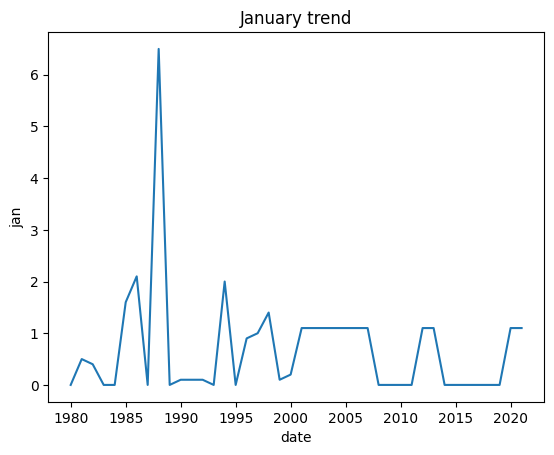

In [44]:
sns.lineplot(x = "date", y = "jan", data =  df)
plt.title("January trend")

### From the above plot, there is no trend in january

## February

In [45]:
f_result = mk.original_test(rainfall["feb"])

In [46]:
print("Test_statistic(S) = ", f_result.s)

Test_statistic(S) =  53.0


In [47]:
print("Variance(S) = ", f_result.var_s)

Variance(S) =  7941.0


In [48]:
print("Standardized Test_statistic(Z) = ", f_result.z)

Standardized Test_statistic(Z) =  0.5835334357351158


In [49]:
print("p_value = ", f_result.p)

p_value =  0.5595342554093488


In [50]:
print("In february there is ", f_result.trend)

In february there is  no trend


In [51]:
f_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.5595342554093488, z=0.5835334357351158, Tau=0.06155632984901278, s=53.0, var_s=7941.0, slope=0.0, intercept=2.75)

### Interpretation: The p_value(0.559) is greater than 0.05, which indicate february trend is not statistically significant

## Visualization

Text(0, 0.5, 'rainfall in february')

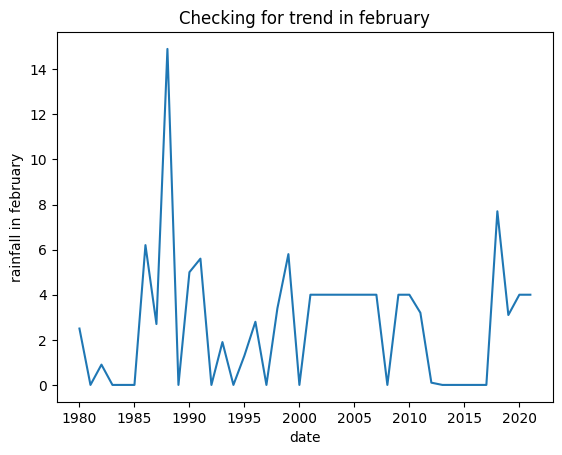

In [52]:
sns.lineplot(x = "date", y = "feb", data = df)
plt.title("Checking for trend in february")
plt.ylabel("rainfall in february")

## March

In [53]:
m_result = mk.original_test(rainfall["mar"])

In [54]:
m_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.11948824233867139, z=-1.5569252138058982, Tau=-0.1672473867595819, s=-144.0, var_s=8436.0, slope=-0.06785714285714285, intercept=11.991071428571429)

In [55]:
print("Test_statistic = ", m_result.s)

Test_statistic =  -144.0


In [56]:
print("Variance(S) = ", m_result.var_s)

Variance(S) =  8436.0


In [57]:
print("Standardize Test_statistic(Z) = ", m_result.z)

Standardize Test_statistic(Z) =  -1.5569252138058982


In [58]:
print("p_value = ", m_result.p)

p_value =  0.11948824233867139


In [59]:
print(m_result.trend, "in March")

no trend in March


### Interpretation: A p_value of 0.119 indicate that the trend is not significant. There is no trend

## Visualization

Text(0, 0.5, 'rainfall in March')

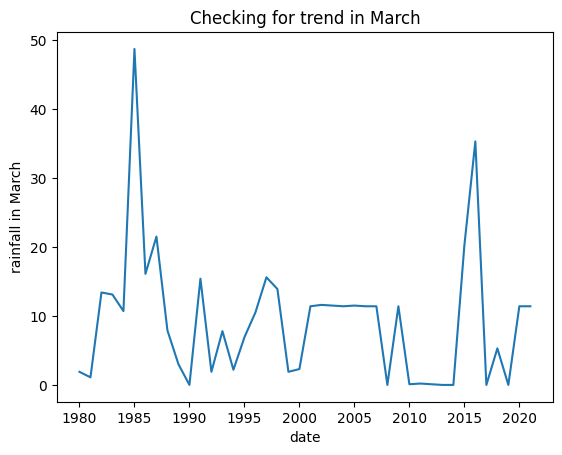

In [60]:
sns.lineplot(x = "date", y = "mar", data = df)
plt.title("Checking for trend in March")
plt.ylabel("rainfall in March")

# April

In [61]:
a_result = mk.original_test(rainfall["apr"])

In [62]:
a_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.6645807966661972, z=-0.4335974364639078, Tau=-0.047619047619047616, s=-41.0, var_s=8510.333333333334, slope=-0.057142857142857446, intercept=57.971428571428575)

In [63]:
print("Test_statistic = ", a_result.s)


Test_statistic =  -41.0


In [64]:
print("Variance(S) = ", a_result.var_s)


Variance(S) =  8510.333333333334


In [65]:
print("Standardize Test_statistic(Z) = ", a_result.z)


Standardize Test_statistic(Z) =  -0.4335974364639078


In [66]:
print("p_value = ", a_result.p)


p_value =  0.6645807966661972


In [67]:
print(a_result.trend, "in April")

no trend in April


## Interpretation: There is no trend in the month of April

##  Visualization

Text(0, 0.5, 'rainfall in April')

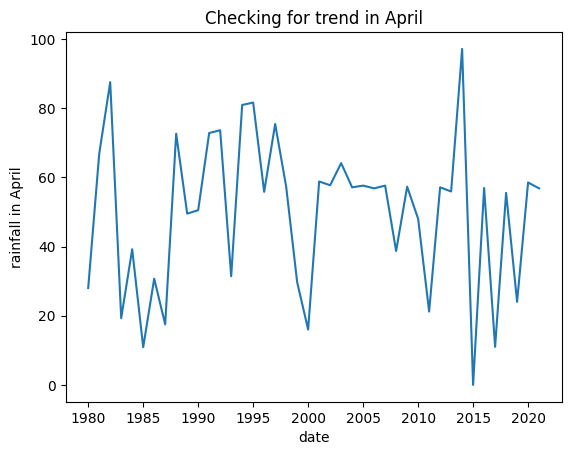

In [68]:
sns.lineplot(x = "date", y = "apr", data = df)
plt.title("Checking for trend in April")
plt.ylabel("rainfall in April")

### There is no increasing or decreasing trend

# May 

In [69]:
may_result = mk.original_test(rainfall["may"])

In [70]:
may_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.7287136307401898, z=0.34683719673427926, Tau=0.03832752613240418, s=33.0, var_s=8512.333333333334, slope=0.12941176470588167, intercept=130.74705882352944)

In [71]:
print("Test_statistic = ", may_result.s)


Test_statistic =  33.0


In [72]:
print("Variance(S) = ", may_result.var_s)


Variance(S) =  8512.333333333334


In [73]:
print("Standardize Test_statistic(Z) = ", may_result.z)


Standardize Test_statistic(Z) =  0.34683719673427926


In [74]:
print("p_value = ", may_result.p)


p_value =  0.7287136307401898


In [75]:
print(m_result.trend, "in May")


no trend in May


## Interpretation: The p_value is > 0.05 which shows that there is no significant trend

## Visualization

Text(0, 0.5, 'rainfall in May')

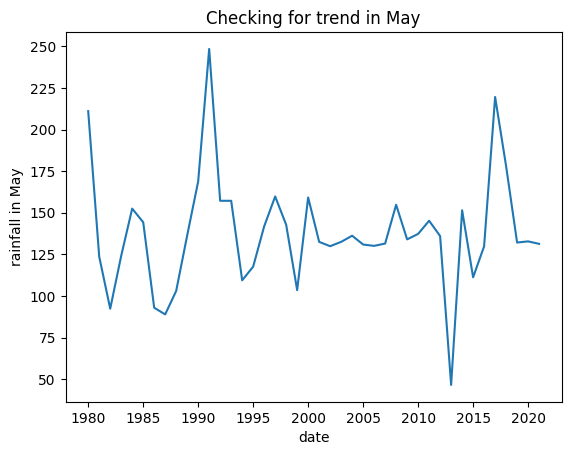

In [76]:
sns.lineplot(x = "date", y = "may", data = df)
plt.title("Checking for trend in May")
plt.ylabel("rainfall in May")

### From the plot the line plot is zigzag which denote no trend

# June

In [77]:
j_result = mk.original_test(rainfall["jun"])

In [78]:
j_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.18967026034195378, z=1.311555190938144, Tau=0.14169570267131243, s=122.0, var_s=8511.333333333334, slope=0.60952380952381, intercept=148.20476190476188)

In [79]:
print("Test_statistic = ", j_result.s)


Test_statistic =  122.0


In [80]:
print("Variance(S) = ", j_result.var_s)


Variance(S) =  8511.333333333334


In [81]:
print("Standardize Test_statistic(Z) = ", j_result.z)


Standardize Test_statistic(Z) =  1.311555190938144


In [82]:
print("p_value = ", j_result.p)


p_value =  0.18967026034195378


In [83]:
print(j_result.trend, "in June")


no trend in June


## Interpretation: With p_value of 0.189 which is greater than 0.05, there is no statistically significance trend

## Visualization

Text(0, 0.5, 'rainfall in June')

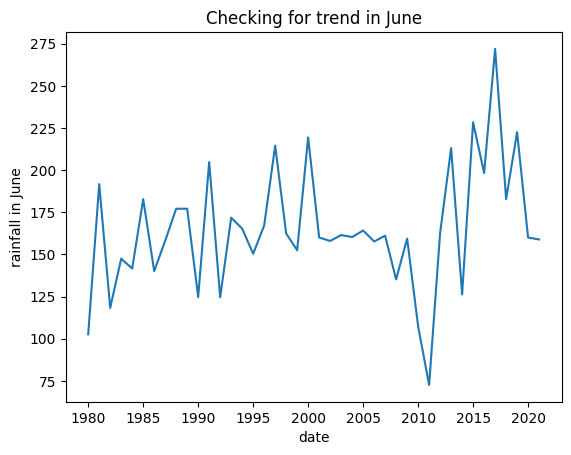

In [84]:
sns.lineplot(x = "date", y = "jun", data = df)
plt.title("Checking for trend in June")
plt.ylabel("rainfall in June")

#### The plot shows no trend

# July 

In [85]:
jul_result = mk.original_test(rainfall["jul"])

In [86]:
jul_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.07544500761422257, z=-1.777749489502022, Tau=-0.1916376306620209, s=-165.0, var_s=8510.333333333334, slope=-0.4794117647058827, intercept=226.3779411764706)

In [87]:
print("Test_statistic = ", jul_result.s)


Test_statistic =  -165.0


In [88]:
print("Variance(S) = ", jul_result.var_s)


Variance(S) =  8510.333333333334


In [89]:
print("Standardize Test_statistic(Z) = ", jul_result.z)


Standardize Test_statistic(Z) =  -1.777749489502022


In [90]:
print("p_value = ", jul_result.p)


p_value =  0.07544500761422257


In [91]:
print(jul_result.trend, "in July")


no trend in July


### Interpretation: Using Mann Kendall test, the p_value is 0.075 which is greater than 0.05. It denotes no trend in July

## Visualization

Text(0, 0.5, 'rainfall in July')

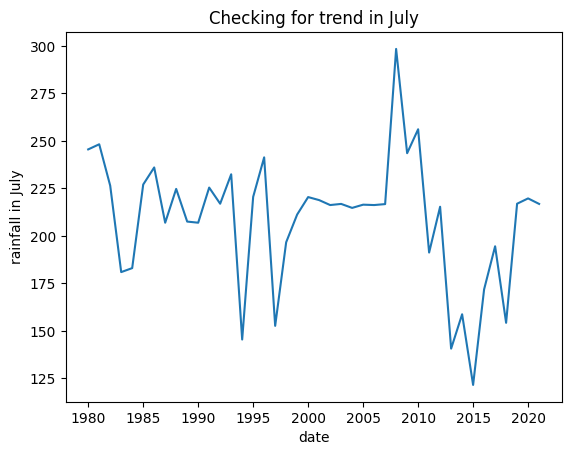

In [92]:
sns.lineplot(x = "date", y = "jul", data = df)
plt.title("Checking for trend in July")
plt.ylabel("rainfall in July")

#### There is no increasing or decreasing trend

# August

In [93]:
aug_result = mk.original_test(rainfall["aug"])

In [94]:
aug_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.8031483824959964, z=-0.24927459361657672, Tau=-0.027874564459930314, s=-24.0, var_s=8513.333333333334, slope=-0.0466666666666697, intercept=257.05666666666673)

In [95]:
print("Test_statistic = ", aug_result.s)


Test_statistic =  -24.0


In [96]:
print("Variance(S) = ", aug_result.var_s)


Variance(S) =  8513.333333333334


In [97]:
print("Standardize Test_statistic(Z) = ", aug_result.z)


Standardize Test_statistic(Z) =  -0.24927459361657672


In [98]:
print("p_value = ", aug_result.p)


p_value =  0.8031483824959964


In [99]:
print(aug_result.trend, "in August")


no trend in August


### Interpretation: There is no trend judging from the p_value(0.80) which is > 0.05. 

## Visualization

Text(0, 0.5, 'rainfall in August')

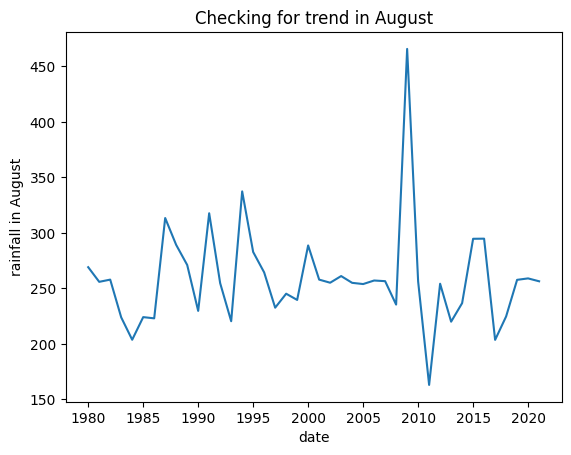

In [100]:
sns.lineplot(x = "date", y = "aug", data = df)
plt.title("Checking for trend in August")
plt.ylabel("rainfall in August")

### There is no increasing or decreasing trend in the month of august

# sept

In [101]:
sep_result = mk.original_test(rainfall["sept"])

In [102]:
sep_result

Mann_Kendall_Test(trend='increasing', h=True, p=0.011214303134345682, z=2.535949103931327, Tau=0.27293844367015097, s=235.0, var_s=8514.333333333334, slope=1.7541666666666664, intercept=209.83958333333334)

In [103]:
print("Test_statistic = ", sep_result.s)


Test_statistic =  235.0


In [104]:
print("Variance(S) = ", sep_result.var_s)


Variance(S) =  8514.333333333334


In [105]:
print("Standardize Test_statistic(Z) = ", sep_result.z)


Standardize Test_statistic(Z) =  2.535949103931327


In [106]:
print("p_value = ", sep_result.p)


p_value =  0.011214303134345682


In [107]:
print("There is an",sep_result.trend,"trend in September")


There is an increasing trend in September


### Interpretation: From the Mann Kendall calculation, the z_score is > 0 which indicate there is an upward increasing trend. 
### Also, the p_value(0.011) is < 0.05 which shows that the trend is statistically significance in September. 
### We can also denote that the z_score > 1.96 which shows that there is 95% probability that the trend observed is not due to random flunctuation 

## Visualization

Text(0, 0.5, 'rainfall in September')

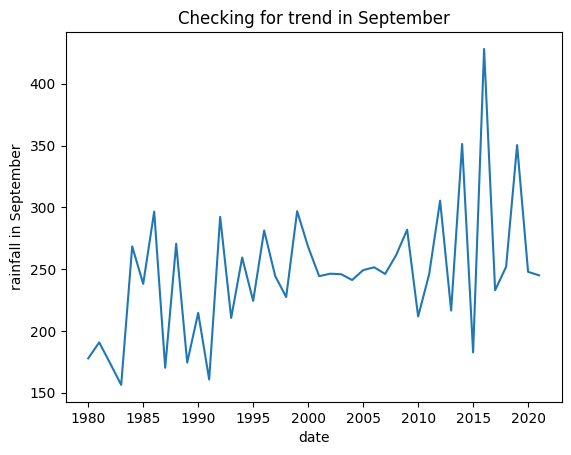

In [108]:
sns.lineplot(x = "date", y = "sept", data = df)
plt.title("Checking for trend in September")
plt.ylabel("rainfall in September")

### From the plot, there is an increasing trend in the month of september

# October

In [109]:
oct_result = mk.original_test(rainfall["oct"])

In [110]:
oct_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.44154299873206915, z=0.7695902360050266, Tau=0.08362369337979095, s=72.0, var_s=8511.333333333334, slope=0.5066666666666673, intercept=94.61333333333332)

In [111]:
print("Test_statistic = ", oct_result.s)


Test_statistic =  72.0


In [112]:
print("Variance(S) = ", oct_result.var_s)


Variance(S) =  8511.333333333334


In [113]:
print("Standardize Test_statistic(Z) = ", oct_result.z)


Standardize Test_statistic(Z) =  0.7695902360050266


In [114]:
print("p_value = ", oct_result.p)


p_value =  0.44154299873206915


In [115]:
print(oct_result.trend, "in October")


no trend in October


### Interpretation: October rainfall shows no trend

## Visualization

Text(0, 0.5, 'rainfall in October')

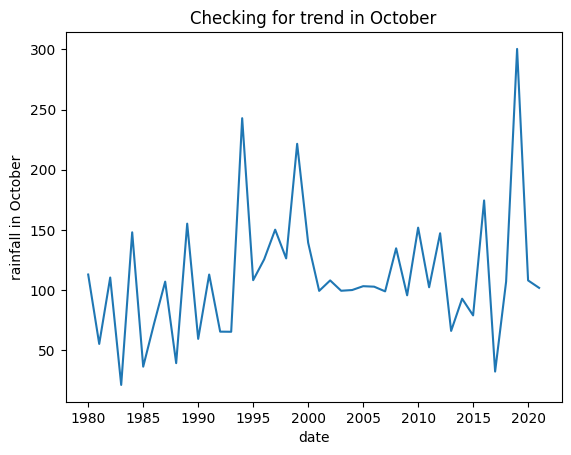

In [116]:
sns.lineplot(x = "date", y = "oct", data = df)
plt.title("Checking for trend in October")
plt.ylabel("rainfall in October")

#### The plot might show a slight trend but statistically(from Mann Kendall test), the trend is not significance at 95% confidence level

# November

In [117]:
nov_result = mk.original_test(rainfall["nov"])

In [118]:
nov_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.21759190044915844, z=1.232956750780932, Tau=0.1254355400696864, s=108.0, var_s=7531.333333333333, slope=0.0, intercept=0.85)

In [119]:
print("Test_statistic = ", nov_result.s)


Test_statistic =  108.0


In [120]:
print("Variance(S) = ", nov_result.var_s)


Variance(S) =  7531.333333333333


In [121]:
print("Standardize Test_statistic(Z) = ", nov_result.z)


Standardize Test_statistic(Z) =  1.232956750780932


In [122]:
print("p_value = ", nov_result.p)


p_value =  0.21759190044915844


In [123]:
print(nov_result.trend, "in November")


no trend in November


### Interpretation: November rainfall shows no trend from Mann Kendall Test

## Visualization

Text(0, 0.5, 'rainfall in November')

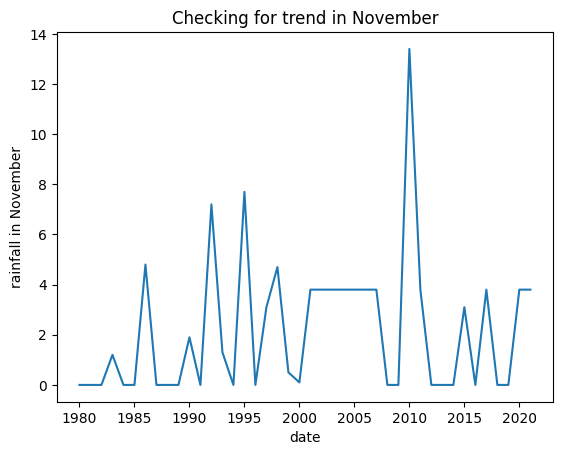

In [124]:
sns.lineplot(x = "date", y = "nov", data = df)
plt.title("Checking for trend in November")
plt.ylabel("rainfall in November")

#### There is no trend at all for November rainfall

# December

In [125]:
dec_result = mk.original_test(rainfall["dec"])

In [126]:
dec_result

Mann_Kendall_Test(trend='increasing', h=True, p=1.7966278243353173e-05, z=4.288773114555404, Tau=0.4343786295005807, s=374.0, var_s=7564.0, slope=0.017391304347826087, intercept=0.5434782608695652)

In [127]:
print("Test_statistic = ", dec_result.s)


Test_statistic =  374.0


In [128]:
print("Variance(S) = ", dec_result.var_s)


Variance(S) =  7564.0


In [129]:
print("Standardize Test_statistic(Z) = ", dec_result.z)


Standardize Test_statistic(Z) =  4.288773114555404


In [130]:
print("p_value = ", dec_result.p)


p_value =  1.7966278243353173e-05


In [131]:
print("There is an",dec_result.trend, "trend in December")


There is an increasing trend in December


### Interpretation: From calculation, the z_score(4.288) is > 0 which indicate there is an upward increasing trend. 
### Also, the p_value(0.0000179) is < 0.05 which shows that the trend is statistically significance in December. 
### We can also denote that the z_score > 1.96 which shows that there is 95% probability that the trend observed is not due to random flunctuation 


Text(0, 0.5, 'rainfall in December')

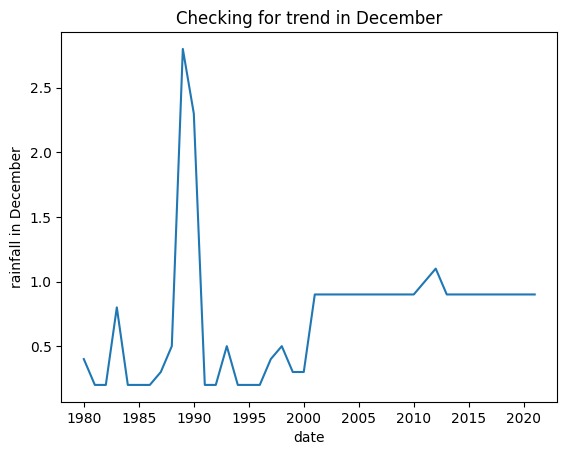

In [132]:
sns.lineplot(x = "date", y = "dec", data = df)
plt.title("Checking for trend in December")
plt.ylabel("rainfall in December")

### Statistically there is trend and visually there is an increasing trend

## Checking for Correlation coefficient among the variables(months) to know if the variables are correlated together

In [133]:
cor_matrix = df.drop(["date"], axis = 1).corr()

In [134]:
cor_matrix

,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
jan,1.000000,0.614461,0.140877,0.257325,-0.322824,0.068184,0.040107,0.060171,0.107948,-0.185657,-0.035505,-0.153923
feb,0.614461,1.000000,-0.039205,0.136934,-0.027039,-0.139680,0.216224,0.107939,0.035296,-0.098901,0.097779,0.015748
mar,0.140877,-0.039205,1.000000,-0.170718,-0.105980,0.181650,-0.095802,0.140720,0.042450,-0.192833,-0.093668,-0.241526
apr,0.257325,0.136934,-0.170718,1.000000,-0.076997,-0.207996,-0.021718,0.225077,0.163021,0.073344,0.082869,-0.048369
may,-0.322824,-0.027039,-0.105980,-0.076997,1.000000,0.095485,0.170994,-0.072716,-0.094291,-0.067186,-0.015115,0.049277
jun,0.068184,-0.139680,0.181650,-0.207996,0.095485,1.000000,-0.334204,0.140440,0.059666,0.041623,-0.263198,-0.025728
jul,0.040107,0.216224,-0.095802,-0.021718,0.170994,-0.334204,1.000000,0.114295,-0.074499,-0.061147,0.142987,-0.093827
aug,0.060171,0.107939,0.140720,0.225077,-0.072716,0.140440,0.114295,1.000000,0.037220,0.189056,-0.162376,-0.072326
sept,0.107948,0.035296,0.042450,0.163021,-0.094291,0.059666,-0.074499,0.037220,1.000000,0.413710,-0.091167,-0.050352
oct,-0.185657,-0.098901,-0.192833,0.073344,-0.067186,0.041623,-0.061147,0.189056,0.413710,1.000000,-0.122636,-0.006436


### From the above correlation coefficient, it shows that only janary and february rainfall have a strong correlated coefficient, oct and sept also has correlation
### In other monthly rainfall, there is a low correlated coefficient

## Visualization

<Axes: >

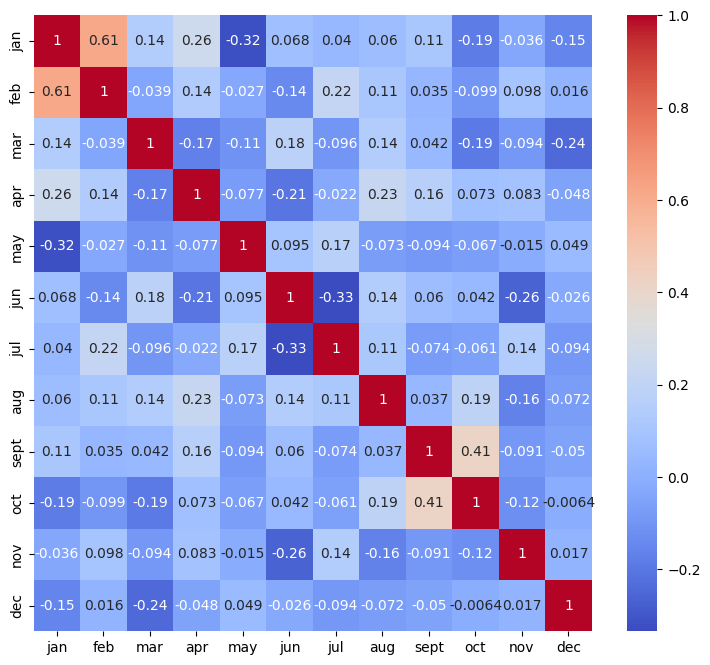

In [135]:
plt.figure(figsize= (9,8))
sns.heatmap(cor_matrix,annot = True,cmap = "coolwarm")

# Summary

### The monthly rainfall are not correlated with each other, which indicates that each monthly rainfall behave differently except from january which behaves similarly with feb and sept correlated with oct

# Checking if the rainfall follows a specific pattern every year.

### NB: It is mandatory to know if a dataset follows a specific patten or not for model selection
### If they follow a specific pattern then the dataset is a seasonal dataset if not, then it is not seasonal

In [136]:
df.set_index("date", inplace = True)

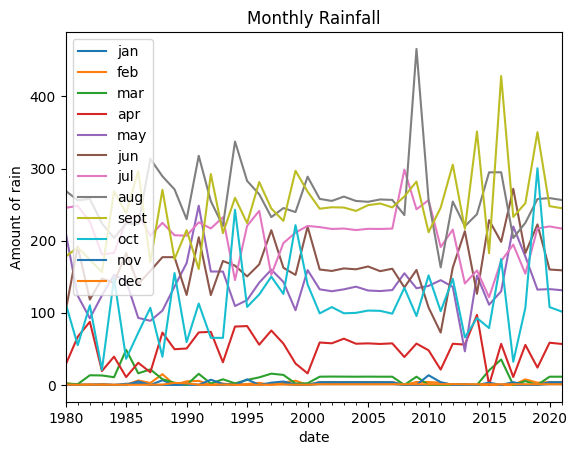

In [137]:

df.plot()
plt.title("Monthly Rainfall")
plt.ylabel("Amount of rain")
plt.xlabel("date")
plt.show()


### From the plot, the rainfall follows a specific pattern, which makes it a seasonal dataset

### A seasonal dataset is a dataset that follows a regular or specific pattern

# Preprocessing the Data for Training

### Converting the dataset into a time series data

In [138]:
rainfall.head()

,date,jan,feb,mar,apr,may,jun,jul,aug,sept,oct,nov,dec
0,1980.0,0.0,2.5,1.9,28.0,211.1,102.6,245.5,269.1,177.8,112.8,0.0,0.4
1,1981.0,0.5,0.0,1.1,66.8,123.6,191.7,248.2,255.9,190.7,55.1,0.0,0.2
2,1982.0,0.4,0.9,13.4,87.5,92.3,118.3,226.4,257.9,173.7,110.3,0.0,0.2
3,1983.0,0.0,0.0,13.1,19.3,124.1,147.5,180.9,223.9,156.3,21.0,1.2,0.8
4,1984.0,0.0,0.0,10.7,39.2,152.5,141.6,183.0,203.7,268.4,147.9,0.0,0.2


In [139]:
rainfall.dtypes

date    float64
jan     float64
feb     float64
mar     float64
apr     float64
may     float64
jun     float64
jul     float64
aug     float64
sept    float64
oct     float64
nov     float64
dec     float64
dtype: object

In [140]:
rainfall.date = rainfall.date.astype(int)

In [141]:
rainfall = rainfall.melt(id_vars = "date", var_name = "months", value_name = "rainfall")

In [142]:
rainfall.head()

,date,months,rainfall
0,1980,jan,0.0
1,1981,jan,0.5
2,1982,jan,0.4
3,1983,jan,0.0
4,1984,jan,0.0


In [143]:
rainfall.tail()

,date,months,rainfall
499,2017,dec,0.9
500,2018,dec,0.9
501,2019,dec,0.9
502,2020,dec,0.9
503,2021,dec,0.9


In [144]:
rainfall.months.unique()

array(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept',
       'oct', 'nov', 'dec'], dtype=object)

In [145]:
rainfall.months = rainfall.months.map({'jan':1 , 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sept':9,
       'oct':10, 'nov':11, 'dec':12})

In [146]:
rainfall.head()

,date,months,rainfall
0,1980,1,0.0
1,1981,1,0.5
2,1982,1,0.4
3,1983,1,0.0
4,1984,1,0.0


In [147]:
import pymannkendall as mk
import pandas as pd

# Perform Mann-Kendall test for each month
trend_results = rainfall.groupby('months')['rainfall'].apply(mk.original_test)

# Extract all parameters and store in a list of dictionaries
results_list = []
for month, result in trend_results.items():
    results_list.append({
        'Month': month,
        'Trend': result.trend,
        'p-value': result.p,
        'z-score': result.z,
        'Tau': result.Tau,
        's': result.s,
        'var_s': result.var_s,
        'slope': result.slope,
        'intercept': result.intercept
    })

# Convert the list of dictionaries to a DataFrame
results_df = pd.DataFrame(results_list)

# Display the DataFrame
results_df

# Save the DataFrame to a CSV file
results_df.to_csv('Rainfall_Trend.csv', index=False)

In [148]:
results_df

,Month,Trend,p-value,z-score,Tau,s,var_s,slope,intercept
0,1,no trend,0.609266,-0.511122,-0.053426,-46.0,7751.333333,0.000000,0.150000
1,2,no trend,0.559534,0.583533,0.061556,53.0,7941.000000,0.000000,2.750000
2,3,no trend,0.119488,-1.556925,-0.167247,-144.0,8436.000000,-0.067857,11.991071
3,4,no trend,0.664581,-0.433597,-0.047619,-41.0,8510.333333,-0.057143,57.971429
4,5,no trend,0.728714,0.346837,0.038328,33.0,8512.333333,0.129412,130.747059
5,6,no trend,0.189670,1.311555,0.141696,122.0,8511.333333,0.609524,148.204762
6,7,no trend,0.075445,-1.777749,-0.191638,-165.0,8510.333333,-0.479412,226.377941
7,8,no trend,0.803148,-0.249275,-0.027875,-24.0,8513.333333,-0.046667,257.056667
8,9,increasing,0.011214,2.535949,0.272938,235.0,8514.333333,1.754167,209.839583
9,10,no trend,0.441543,0.769590,0.083624,72.0,8511.333333,0.506667,94.613333


In [149]:
rainfall.head()

,date,months,rainfall
0,1980,1,0.0
1,1981,1,0.5
2,1982,1,0.4
3,1983,1,0.0
4,1984,1,0.0


In [150]:
rainfall["date"] = pd.to_datetime(rainfall["date"].astype(str) + "-" + rainfall["months"].astype(str), format = "%Y-%m")

In [151]:
rainfall.head()

,date,months,rainfall
0,1980-01-01,1,0.0
1,1981-01-01,1,0.5
2,1982-01-01,1,0.4
3,1983-01-01,1,0.0
4,1984-01-01,1,0.0


In [152]:
rainfall.tail()

,date,months,rainfall
499,2017-12-01,12,0.9
500,2018-12-01,12,0.9
501,2019-12-01,12,0.9
502,2020-12-01,12,0.9
503,2021-12-01,12,0.9


In [153]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      504 non-null    datetime64[ns]
 1   months    504 non-null    int64         
 2   rainfall  504 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 11.9 KB


In [154]:
rainfall = rainfall.drop(rainfall[["months"]], axis = 1)

In [155]:
rainfall

,date,rainfall
0,1980-01-01,0.0
1,1981-01-01,0.5
2,1982-01-01,0.4
3,1983-01-01,0.0
4,1984-01-01,0.0
...,...,...
499,2017-12-01,0.9
500,2018-12-01,0.9
501,2019-12-01,0.9
502,2020-12-01,0.9


In [156]:
rainfall = rainfall.sort_values(by = "date")

In [157]:
rainfall.head()

,date,rainfall
0,1980-01-01,0.0
42,1980-02-01,2.5
84,1980-03-01,1.9
126,1980-04-01,28.0
168,1980-05-01,211.1


In [158]:
rainfall.set_index(["date"], inplace = True)

In [159]:
rainfall

,rainfall
date,
1980-01-01,0.0
1980-02-01,2.5
1980-03-01,1.9
1980-04-01,28.0
1980-05-01,211.1
...,...
2021-08-01,256.4
2021-09-01,245.0
2021-10-01,101.7


In [184]:
rainfall_s = rainfall.copy()

In [186]:
rainfall_s = rainfall_s/465.8

# Spliting the data into Training and Testing Dataset

### Let the train data be from 1980 to 2015 and the validation data be from 2016 to 2021

In [188]:
train = rainfall_s.loc["1980":"2015"]
test = rainfall_s.loc["2016":"2021"]

In [189]:
train.head()

,rainfall
date,
1980-01-01,0.000000
1980-02-01,0.005367
1980-03-01,0.004079
1980-04-01,0.060112
1980-05-01,0.453199


In [190]:
test.head()

,rainfall
date,
2016-01-01,0.000000
2016-02-01,0.000000
2016-03-01,0.075784
2016-04-01,0.122155
2016-05-01,0.278660


In [191]:
train.max()

rainfall    1.0
dtype: float64

In [192]:
test.max()

rainfall    0.919279
dtype: float64

### To train the model, we need to check for stationarity of data in the training dataset
### A data is said to be stationary if its statistical properties(mean, variance, autocorrelation) do not change overtime

## Checking For stationarity 
### Augmented Dickey Fuller Test aslo know as adfuller test is a test used to check for stationarity

In [193]:
from statsmodels.tsa.stattools import adfuller

In [194]:
full = adfuller(rainfall["rainfall"])

In [195]:
full

(-5.399330628696759,
 3.398186246729969e-06,
 16,
 487,
 {'1%': -3.443849184997939,
  '5%': -2.8674931065091105,
  '10%': -2.569940776113236},
 4916.667548094697)

In [196]:
fullout = pd.Series(full[0:4], index = ("test_statistics", "p-value", "lags", "observations"))

In [197]:
fullout

test_statistics     -5.399331
p-value              0.000003
lags                16.000000
observations       487.000000
dtype: float64

### From the above test, the p-value is < than 0.05 which shows that  the data is stationary. It rejects the null hypothesis

# Training the model for prediction and forecasting

In [198]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [199]:
import statsmodels.api as sm

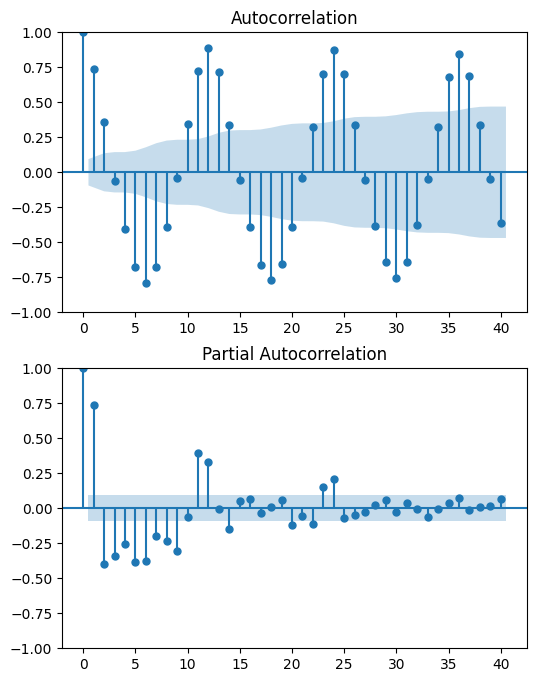

In [200]:
fig = plt.figure(figsize = (6,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(train["rainfall"], lags = 40, ax = ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(train["rainfall"], lags = 40 , ax = ax2)

In [201]:
#p = 4, q = 7 d = 0

In [208]:
model = sm.tsa.statespace.SARIMAX(train["rainfall"], order = (3,1,2), seasonal_order = (2,1,2,12))
result = model.fit()

C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Prediction on The Test data

In [209]:
predictions = result.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
predicted_means = predictions.predicted_mean

In [210]:
predicted_means

2016-01-01   -0.006842
2016-02-01   -0.000907
2016-03-01    0.005381
2016-04-01    0.114967
2016-05-01    0.285827
                ...   
2021-08-01    0.550770
2021-09-01    0.520194
2021-10-01    0.219916
2021-11-01   -0.004480
2021-12-01   -0.008269
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64

In [175]:
#train['rainfall_log'] = np.log1p(train['rainfall'])  # log(1 + x) to avoid log(0)

In [176]:
rainfall.head()

,rainfall
date,
1980-01-01,0.0
1980-02-01,2.5
1980-03-01,1.9
1980-04-01,28.0
1980-05-01,211.1


In [177]:
test.loc["2017"]

,rainfall
date,
2017-01-01,0.0
2017-02-01,0.0
2017-03-01,0.0
2017-04-01,11.0
2017-05-01,219.6
2017-06-01,271.9
2017-07-01,194.5
2017-08-01,203.6
2017-09-01,232.9


In [178]:
from sklearn.metrics import r2_score, mean_absolute_error

In [179]:
r2_score(test, predicted_means)

0.8571617943869716

In [180]:
mean_absolute_error(test, predicted_means)

20.754872243472164

## Training January rainfall and making prediction

In [176]:
# Example for forecasting January rainfall for 2025
model_jan = SARIMAX(train['jan'], 
                   order=(1, 1, 0), 
                   seasonal_order=(1, 1, 0, 12),
                   enforce_stationarity=False,
                   enforce_invertibility=False)
results_jan = model_jan.fit()


C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [177]:
# Forecast for January 2025
forecast_jan = results_jan.get_forecast(len(test["jan"]))
forecast_jan_value = forecast_jan.predicted_mean
print(f"Forecasted January 2025 rainfall: {forecast_jan_value}")

Forecasted January 2025 rainfall: 2011-01-01   -0.359660
2012-01-01   -6.952204
2013-01-01    0.602049
2014-01-01    0.378472
2015-01-01    0.477473
2016-01-01    0.398160
2017-01-01    0.561700
2018-01-01   -1.489204
2019-01-01    0.551577
2020-01-01   -1.481094
2021-01-01   -1.554920
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("rainfall_data.csv")  # Ensure the format is Year, Jan, Feb, ..., Dec
df.set_index("Year", inplace=True)

# Split into training (1980–2010) and testing (2011–2021)
train = df.loc[1980:2010]
test = df.loc[2011:2021]

# Dictionary to store trained models and evaluation metrics
sarima_models = {}
metrics = {}

# Train SARIMA for each month
for month in df.columns:
    print(f"\n--- Training SARIMA for {month} ---")

    # Get SARIMA parameters (you should have these from previous analysis)
    params = sarima_params[month]  # Use previously determined parameters

    # Fit SARIMA model on training data (1980–2010)
    model = SARIMAX(train[month], 
                    order=params["order"], 
                    seasonal_order=params["seasonal_order"], 
                    enforce_stationarity=False, 
                    enforce_invertibility=False)
    
    results = model.fit()
    sarima_models[month] = results  # Store trained model

    # Forecast for test period (2011–2021)
    predictions = results.get_forecast(steps=len(test))
    pred_values = predictions.predicted_mean

    # Evaluate with MAE and RMSE
    mae = mean_absolute_error(test[month], pred_values)
    rmse = np.sqrt(mean_squared_error(test[month], pred_values))

    metrics[month] = {"MAE": mae, "RMSE": rmse}

    # Plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(test.index, test[month], label="Actual", marker="o")
    plt.plot(test.index, pred_values, label="Predicted", marker="o", linestyle="dashed")
    plt.title(f"{month} - Actual vs Predicted")
    plt.legend()
    plt.show()

# Print evaluation metrics
print("\nModel Evaluation Results:")
for month, metric in metrics.items():
    print(f"{month}: MAE={metric['MAE']:.2f}, RMSE={metric['RMSE']:.2f}")


In [ ]:
# Dictionary to store forecasts
forecasts = pd.DataFrame(index=range(2022, 2026), columns=df.columns)

# Forecasting 2022–2025 for each month
for month in df.columns:
    print(f"\n--- Forecasting {month} for 2022–2025 ---")

    # Get trained model
    model = sarima_models[month]

    # Forecast for next 4 years (48 months)
    future_forecast = model.get_forecast(steps=48)  # 4 years × 12 months
    future_values = future_forecast.predicted_mean

    # Assign values to correct years in DataFrame
    for i, year in enumerate(range(2022, 2026)):
        forecasts.loc[year, month] = future_values[i * 12]  # Extract first value of each year

# Display forecasted rainfall
print("\nFinal Rainfall Forecast for 2022–2025:")
print(forecasts)
